# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns,
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN}
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$.

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [2]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication.

In [3]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

print(A@e_1)
print(A@e_2)
print(A@e_3)

[1 4 7]
[2 5 8]
[3 6 9]


Each operation chooses one column of the matrix to multiply by, so e_1 multiplys by the first column, e_2 is the second, and e_3 is the third. This is expected given the definition of matrix multiplication, since the formula takes the dot product and since two of the three numbers in each vector are zero we only use these specific columns.

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [4]:
u = np.ones(3)
A@u

array([ 6., 15., 24.])

Since all values within the vector are 1, the resulting vector is based on the row sums of the original matrix.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [5]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])


A@x


array([-2,  4, 11])

In [6]:
x@A

array([-2,  4, 11])

Multiplying any vector by an identity matrix results in the original vector being returned. This is because the identity matrix has 1s on the diagonal and 0s elsewhere, so each component of the vector is multiplied by 1 and all others by 0, leaving it unchanged. Multiplying an identity matrix by a vector yields the original vector as well.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$.

In [7]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])

print(A@x)

A = np.array([[0,1,0],
             [0,0,1],
             [1,0,0]])
print(A@x)

[11 -2  4]
[ 4 11 -2]


This results in the values of the vector being shifted, but the three values themselves stay the same as the original matrix. This makes sense because of how matricies are multiplied, with each element being the dot product of elements from the original matrix and vector. Since the location of the values has moved from the diagonal, our matrix is shifted but retains the original vector values due to each column and row summing to 1.

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [8]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)


[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [9]:

A@e_1


array([0.50052958, 0.02574731, 0.47372311])

In [10]:

A@e_2


array([0.24049286, 0.39251588, 0.36699127])

In [11]:
A@e_3

array([0.18358131, 0.37907577, 0.43734292])

Multiplying the matrix by each of these vectors isolates a column of A, and each result provides the next step distribution of the population.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [12]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

print("Results for e_1:")
current_e1 = e_1.copy()
for i in range(5):
    current_e1 = A @ current_e1
    print(f"After {i+1} multiplication(s): {current_e1}")

print("\nResults for e_2:")
current_e2 = e_2.copy()
for i in range(5):
    current_e2 = A @ current_e2
    print(f"After {i+1} multiplication(s): {current_e2}")

print("\nResults for e_3:")
current_e3 = e_3.copy()
for i in range(5):
    current_e3 = A @ current_e3
    print(f"After {i+1} multiplication(s): {current_e3}")

Results for e_1:
After 1 multiplication(s): [0.50052958 0.02574731 0.47372311]
After 2 multiplication(s): [0.34368862 0.20257047 0.45374091]
After 3 multiplication(s): [0.30404142 0.26036337 0.43559521]
After 4 multiplication(s): [0.29476439 0.27514859 0.43008701]
After 5 multiplication(s): [0.29266551 0.27862515 0.42870935]

Results for e_2:
After 1 multiplication(s): [0.24049286 0.39251588 0.36699127]
After 2 multiplication(s): [0.28214379 0.29937825 0.41847795]
After 3 multiplication(s): [0.29004438 0.28341002 0.42654561]
After 4 multiplication(s): [0.29163968 0.2804039  0.42795643]
After 5 multiplication(s): [0.29197422 0.27979983 0.42822595]

Results for e_3:
After 1 multiplication(s): [0.18358131 0.37907577 0.43734292]
After 2 multiplication(s): [0.26334088 0.31930609 0.41735304]
After 3 multiplication(s): [0.28521895 0.29032145 0.4244596 ]
After 4 multiplication(s): [0.29050361 0.28220175 0.42729464]
After 5 multiplication(s): [0.29171646 0.2802254  0.42805814]


The three vectors seem to converge in the long run.

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right]
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes.


In [13]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [14]:
init_condition = np.array([1,0])
init_condition

array([1, 0])

In [15]:
p_1 = T @ init_condition
p_1

array([0.25, 0.75])

This is the first column of the array. Since we are multiplying by [1,0] we get the resulting array.

In [16]:
p_2 = T @ p_1
p_2

array([0.4375, 0.5625])

This is a forecast of future predictions based on the past data. Using matrix multiplication we can take the steady state initial prediction and get a range of outcomes. The information as we get further from the steady state starts to become a guess at the long run average and is less specific.

In [17]:
p_3 = T@p_2
p_3

array([0.390625, 0.609375])

In [18]:
p_4 = T@p_3
p_4

array([0.40234375, 0.59765625])

In [19]:
p_5=T@p_4
p_5

array([0.39941406, 0.60058594])

It looks to settle around [.4,.6].

In [20]:
init_condition = ([0,1])

In [21]:
p_1 = T @ init_condition
p_1

array([0.5, 0.5])

In [22]:
p_2=T@p_1
p_2

array([0.375, 0.625])

In [23]:
p_3 = T@p_2
p_3

array([0.40625, 0.59375])

In [24]:
p_4 = T@p_3
p_4

array([0.3984375, 0.6015625])

In [25]:
p_5 = T@p_4
p_5

array([0.40039062, 0.59960938])

Given this new steady state, our initial prediction settles at the same [.4,.6] in the long run, but closer to our steady state we see [.5,.5] instead of the much wider range of [.25,.75]. This is because it now takes the second column instead of the first.

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable.
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [26]:
import pandas as pd
df = pd.read_csv("cville_weather.csv")

import pandas as pd

# Load dataset
df = pd.read_csv("cville_weather.csv")

# Check for any missing values
print("Missing Values by Column")
print(df.isnull().sum())

# Optionally: show percentage of missing values
print("\nPercentage of Missing Values")
print((df.isnull().mean() * 100).round(2))

# If you just want to know if the dataset has any missing values at all:
print("\nAny missing values in dataset?:", df.isnull().values.any())


Missing Values by Column
STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64

Percentage of Missing Values
STATION             0.00
NAME                0.00
DATE                0.00
DAPR               97.08
DAPR_ATTRIBUTES    97.08
MDPR               97.08
MDPR_ATTRIBUTES    97.08
PRCP                2.92
PRCP_ATTRIBUTES     2.92
SNOW               45.74
SNOW_ATTRIBUTES    45.74
SNWD               99.76
SNWD_ATTRIBUTES    99.76
dtype: float64

Any missing values in dataset?: True


There appear to be a lot of missing values, especially in DAPR, MDPR, and Snow and SNWD related categories. These missing values are largely inconstent, and could likely be replaced with 0.

In [27]:
import pandas as pd

# Load the dataset
df = pd.read_csv("cville_weather.csv")

# Create a new binary column: 1 if PRCP > 0, else 0
df["rain"] = (df["PRCP"] > 0).astype(int)

# Display the first few rows to confirm
print(df[["PRCP", "rain"]].head())

   PRCP  rain
0  0.03     1
1  1.08     1
2  0.24     1
3  3.00     1
4  0.00     0


In [41]:
# Shift the rain column to create consecutive day pairs
df["next_rain"] = df["rain"].shift(-1)

# Drop the last row (no next day)
df = df.dropna(subset=["next_rain"])

# Compute transition counts
transition_counts = pd.crosstab(df["rain"], df["next_rain"])

# Convert to probabilities
transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

print("Transition counts:")
print(transition_counts)
print("\nTransition probabilities:")
print(transition_probs)

Transition counts:
next_rain  0.0  1.0
rain               
0          169   62
1           63  116

Transition probabilities:
next_rain       0.0       1.0
rain                         
0          0.731602  0.268398
1          0.351955  0.648045


The probability that it rains today if it rained yesterday is  64%, based on the 1,1 cell in our transition probabilities matrix. The probability that it rains if it was clear the previous day is 26.8%, as seen in the 1,0 cell.

In [42]:
# Transition matrix
counts = pd.crosstab(df["rain"], df["next_rain"])
P = counts.div(counts.sum(axis=1), axis=0).to_numpy()

# Stationary distribution
A = (P.T - np.eye(2))
A[0] = np.array([1.0, 1.0])
b = np.array([1.0, 0.0])
pi = np.linalg.lstsq(A, b, rcond=None)[0]

# Function to find when probabilities stabilize
def steps_to_converge(P, p0, pi, tol=1e-6, max_days=10000):
    p = p0.copy()
    for n in range(1, max_days + 1):
        p = p @ P
        if np.sum(np.abs(p - pi)) < tol:
            return n, p
    return None, p

# Start from clear or rain
p0_clear = np.array([1.0, 0.0])
p0_rain = np.array([0.0, 1.0])

steps_clear, _ = steps_to_converge(P, p0_clear, pi)
steps_rain, _ = steps_to_converge(P, p0_rain, pi)

print("Transition matrix:\n", P)
print("Stationary distribution (clear, rain):", pi)
print(f"Days to converge from clear: {steps_clear}")
print(f"Days to converge from rain: {steps_rain}")

Transition matrix:
 [[0.73160173 0.26839827]
 [0.35195531 0.64804469]]
Stationary distribution (clear, rain): [0.5673463 0.4326537]
Days to converge from clear: 15
Days to converge from rain: 15


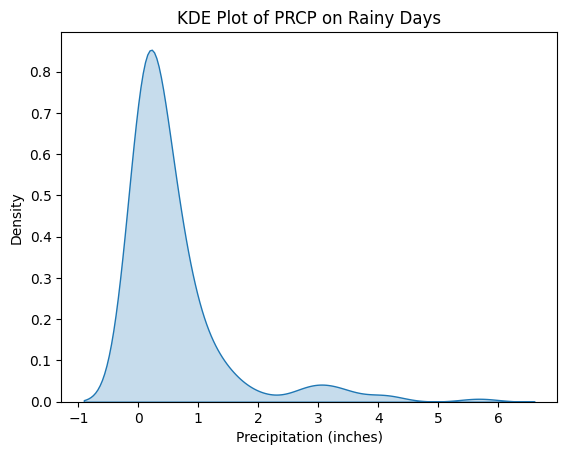

In [43]:
# Keep rainy days
rainy = df[df["PRCP"] > 0]

# KDE plot
sns.kdeplot(data=rainy, x="PRCP", fill=True)
plt.title("KDE Plot of PRCP on Rainy Days")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Density")
plt.show()

One way this model could be improved is by accounting for how much rain there was when predicting the likelihood of the following day being rainy. We would expect that on days with more rain, the next day is more likely to be rainy than it would be after an average rainy day.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle


In [29]:
with open('taxicab.pkl', 'rb') as f:
    data = pickle.load(f)

print(len(data))
data[0]

1000


,nbhd
0,Outside Manhattan
0,Outside Manhattan
0,Outside Manhattan
0,Outside Manhattan
0,Outside Manhattan
...,...
29,SoHo
29,SoHo
13,Greenwich Village
3,Chelsea


In [30]:
states = set(data[0])
for i in range(1,len(data)):
    trip_i=set(data[i])
    states = states.union(trip_i)
states = list(states)

In [31]:
S = len(states)
tr_counts = np.zeros((S,S))

In [32]:
for trip in data:
  seq = np.array(trip)
  for t in range(1,len(seq)):
    x_tm1 = seq[t-1]
    x_t = seq[t]
    index_from=states.index(x_tm1)
    index_to=states.index(x_t)
    tr_counts[index_to,index_from]+=1
print('Transition Counts:', tr_counts)

Transition Counts: [[1.398000e+04 1.981400e+04 6.652000e+03 ... 6.291000e+03 2.690000e+02
  2.000000e+01]
 [1.155800e+04 1.203902e+06 7.178700e+04 ... 4.892200e+04 1.886200e+04
  9.790000e+02]
 [8.575000e+03 7.774300e+04 2.373110e+05 ... 5.553000e+04 4.039000e+03
  1.650000e+02]
 ...
 [1.012500e+04 8.664700e+04 2.809600e+04 ... 7.824000e+04 1.351000e+03
  4.400000e+01]
 [3.460000e+02 2.594400e+04 4.643000e+03 ... 2.009000e+03 7.192200e+04
  3.720000e+02]
 [2.100000e+01 1.453000e+03 3.280000e+02 ... 1.470000e+02 3.140000e+02
  9.800000e+02]]


In [33]:
sums = tr_counts.sum(axis=0, keepdims=True)
print(sums)

[[1.058700e+05 2.363902e+06 8.886410e+05 3.000000e+00 6.544000e+05
  4.930000e+02 1.063810e+05 5.017520e+05 1.200000e+01 3.603000e+03
  4.086350e+05 5.077810e+05 5.505930e+05 1.743200e+05 1.627100e+05
  2.797710e+06 1.803502e+06 8.740570e+05 1.038800e+04 8.010000e+03
  1.224335e+06 3.952900e+05 3.851989e+06 1.112820e+05 3.859100e+04
  2.292350e+05 8.393600e+05 7.252200e+04 5.102590e+05 5.791000e+04
  1.978286e+06 1.000000e+00 3.701250e+05 2.171460e+05 4.415730e+05
  3.705730e+05 3.168450e+05 1.431100e+04]]


In [34]:
tr_pr = np.divide(tr_counts, sums, out=np.zeros_like(tr_counts), where=sums!=0)
print('Transition Probabilities:')
tr_df = pd.DataFrame(tr_pr, index=states, columns=states)
tr_df

Transition Probabilities:


,Chinatown,Outside Manhattan,East Village,Ellis Island,Murray Hill,Marble Hill,Nolita,Gramercy,Governors Island,Randall's Island,...,Greenwich Village,Civic Center,Chelsea,Liberty Island,Central Park,Harlem,Financial District,Lower East Side,East Harlem,Inwood
Chinatown,0.132049,8.381904e-03,0.007486,0.000000,0.002129,0.000000,0.011797,0.004189,0.000000,0.000555,...,0.005397,0.033069,2.576978e-03,0.0,0.000800,0.000857,0.019118,0.016976,0.000849,0.001398
Outside Manhattan,0.109172,5.092859e-01,0.080783,0.333333,0.058901,0.113590,0.105724,0.054906,0.333333,0.171246,...,0.058517,0.093904,4.699219e-02,0.0,0.033780,0.058620,0.078546,0.132017,0.059531,0.068409
East Village,0.080996,3.288757e-02,0.267049,0.000000,0.033950,0.004057,0.086989,0.082587,0.083333,0.005273,...,0.074915,0.044880,2.658817e-02,0.0,0.006398,0.008897,0.040478,0.149849,0.012748,0.011530
Ellis Island,0.000000,4.230294e-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000002,0.000000,0.000000,0.000000
Murray Hill,0.014489,1.464189e-02,0.029114,0.000000,0.195619,0.006085,0.018067,0.047478,0.000000,0.010547,...,0.019521,0.015248,2.119966e-02,0.0,0.009437,0.005296,0.014614,0.018787,0.009787,0.006009
Marble Hill,0.000038,4.568717e-05,0.000008,0.000000,0.000011,0.032454,0.000000,0.000006,0.000000,0.000000,...,0.000008,0.000017,1.263720e-05,0.0,0.000014,0.000064,0.000011,0.000000,0.000050,0.000559
Nolita,0.023463,6.245183e-03,0.007610,0.000000,0.002340,0.002028,0.158280,0.004775,0.000000,0.000555,...,0.006677,0.014592,3.166883e-03,0.0,0.000813,0.000764,0.005666,0.017033,0.000742,0.001048
Gramercy,0.022858,1.051059e-02,0.068943,0.000000,0.031884,0.004057,0.031293,0.175483,0.083333,0.003886,...,0.032372,0.013745,2.010276e-02,1.0,0.005150,0.004232,0.010456,0.034190,0.006467,0.004193
Governors Island,0.000019,8.460588e-07,0.000001,0.000000,0.000002,0.000000,0.000000,0.000000,0.166667,0.000000,...,0.000000,0.000000,5.054881e-07,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Randall's Island,0.000085,3.363084e-04,0.000084,0.000000,0.000112,0.000000,0.000028,0.000062,0.000000,0.177352,...,0.000043,0.000035,5.155978e-05,0.0,0.000154,0.000442,0.000029,0.000059,0.000855,0.000000


<Axes: >

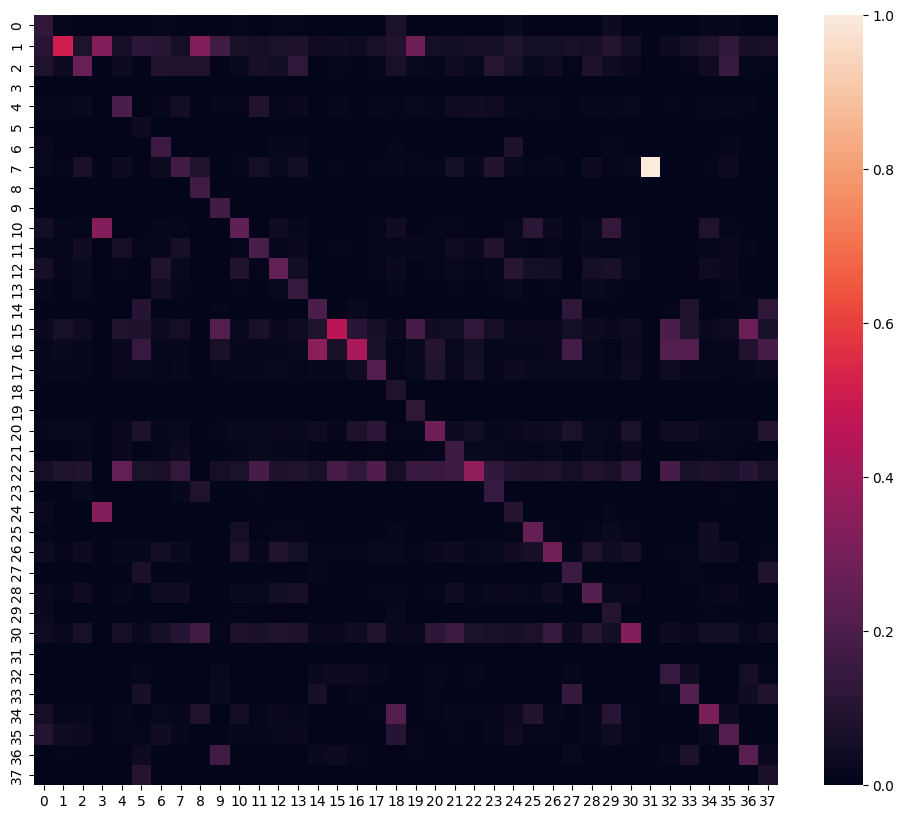

In [35]:
plt.figure(figsize=(12,10))
sns.heatmap(tr_pr)

Taxis are order 1 not 2 because drivers cannot choose which trips to take and not to take, so the state of where you are going with your current passenger is unrelated to the previous passenger or location.

In [36]:
# Start at Hell's Kitchen
initial_state = np.zeros(len(states))
initial_state[states.index("Hell's Kitchen")] = 1

# Function to find probabilities after n trips
def forecast_after_n_steps(initial_state, transition_matrix, n):
    result = initial_state @ np.linalg.matrix_power(transition_matrix, n)
    return pd.Series(result, index=states)

# Forecast after 2, 3, 5, and 10 trips
for trips in [2, 3, 5, 10]:
    forecast = forecast_after_n_steps(initial_state, tr_pr, trips)
    print(f"Forecast after {trips} trips:")
    print(forecast.round(3), "\n")

Forecast after 2 trips:
Chinatown              0.032
Outside Manhattan      0.033
East Village           0.035
Ellis Island           0.024
Murray Hill            0.045
Marble Hill            0.070
Nolita                 0.034
Gramercy               0.040
Governors Island       0.026
Randall's Island       0.029
Tribeca                0.040
Kips Bay               0.040
SoHo                   0.039
NoHo                   0.036
Morningside Heights    0.061
Upper East Side        0.037
Upper West Side        0.074
Theater District       0.087
Two Bridges            0.028
Roosevelt Island       0.034
Hell's Kitchen         0.119
Flatiron District      0.048
Midtown                0.056
Stuyvesant Town        0.036
Little Italy           0.039
Battery Park City      0.043
West Village           0.050
Washington Heights     0.069
Greenwich Village      0.041
Civic Center           0.033
Chelsea                0.068
Liberty Island         0.022
Central Park           0.055
Harlem             

In [49]:
# AI Assisted Code
# The transition matrix tr_pr has columns summing to 1, so we need the left eigenvector of P=tr_pr
P = tr_pr

# Find the eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(P)

# Find the index of the eigenvalue closest to 1
# For a valid transition matrix, there should be an eigenvalue of 1
stationary_index = np.isclose(eigenvalues, 1).argmax()

# Get the corresponding eigenvector (left eigenvector is rows of the right eigenvector matrix)
stationary_vector = np.real(eigenvectors[:, stationary_index])

# Normalize the vector so that its elements sum to 1
stationary_distribution = stationary_vector / np.sum(stationary_vector)

# Ensure the distribution is non-negative (can sometimes have small negative due to float precision)
stationary_distribution[stationary_distribution < 0] = 0
stationary_distribution = stationary_distribution / np.sum(stationary_distribution) # Re-normalize after setting negative to zero


pi = pd.Series(stationary_distribution, index=states).sort_values(ascending=False)

print("Long-run distribution:")
print(pi.round(4))
print(f"\nCabs spend the most time in: {pi.idxmax()} (~{pi.max():.2%})")

Long-run distribution:
Midtown                0.1677
Upper East Side        0.1218
Outside Manhattan      0.1030
Chelsea                0.0862
Upper West Side        0.0785
Hell's Kitchen         0.0533
East Village           0.0387
Theater District       0.0381
West Village           0.0366
Murray Hill            0.0285
SoHo                   0.0240
Greenwich Village      0.0222
Kips Bay               0.0221
Gramercy               0.0219
Financial District     0.0192
Tribeca                0.0178
Flatiron District      0.0172
Lower East Side        0.0161
Central Park           0.0161
East Harlem            0.0138
Battery Park City      0.0100
Harlem                 0.0095
NoHo                   0.0076
Morningside Heights    0.0071
Stuyvesant Town        0.0048
Nolita                 0.0046
Chinatown              0.0046
Washington Heights     0.0032
Civic Center           0.0025
Little Italy           0.0017
Inwood                 0.0006
Two Bridges            0.0005
Roosevelt Island 